In [39]:
import pandas as pd
import numpy as np
import os
import pickle
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df_text = pd.read_csv('../../../data/cleaned_data.csv').dropna()
df_emotions = pd.read_csv('../../../data/features_for_model.csv').dropna()
combined_df = pd.concat([df_text.reset_index(drop=True), 
                         df_emotions.reset_index(drop=True)], axis=1).dropna()


In [43]:
emotion_cols = df_emotions.columns[:-1].tolist()
X = combined_df[emotion_cols]
y = combined_df.iloc[:, -1]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Liczność klas zbioru treningowego:\n{y_train.value_counts()}")
print(f"Liczność klas zbioru testowego:\n{y_test.value_counts()}")

Liczność klas zbioru treningowego:
target_label
1    12798
0    12790
Name: count, dtype: int64
Liczność klas zbioru testowego:
target_label
1    3200
0    3197
Name: count, dtype: int64


In [46]:
search_spaces = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(5, 50),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2', None]),
    'criterion': Categorical(['gini', 'entropy']),
    'min_impurity_decrease': Real(0.0, 0.2, prior='uniform')
}

In [47]:
rf_base = RandomForestClassifier(random_state=42)
bayes_search = BayesSearchCV(
    estimator=rf_base,
    search_spaces=search_spaces,
    n_iter=32,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    random_state=42
)
bayes_search.fit(X_train, y_train)
best_params = bayes_search.best_params_
print("Najlepsze parametry:", best_params)

Najlepsze parametry: OrderedDict({'criterion': 'gini', 'max_depth': 50, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500})


In [48]:
best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))
print("Macierz pomyłek:\n", confusion_matrix(y_test, y_pred))

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88      3197
           1       0.89      0.87      0.88      3200

    accuracy                           0.88      6397
   macro avg       0.88      0.88      0.88      6397
weighted avg       0.88      0.88      0.88      6397

Macierz pomyłek:
 [[2855  342]
 [ 417 2783]]


In [51]:
model_tuned_dict = {
    'model': best_model,
    'emotion_cols': emotion_cols,
    'metadata': {
        'feature_count': X.shape[1],
        'samples': len(X)
    }
}

os.makedirs('../local_models', exist_ok=True)
file_path = '../local_models/safety_model_tuned_bayes.pkl'

with open(file_path, 'wb') as f:
    pickle.dump(model_tuned_dict, f)

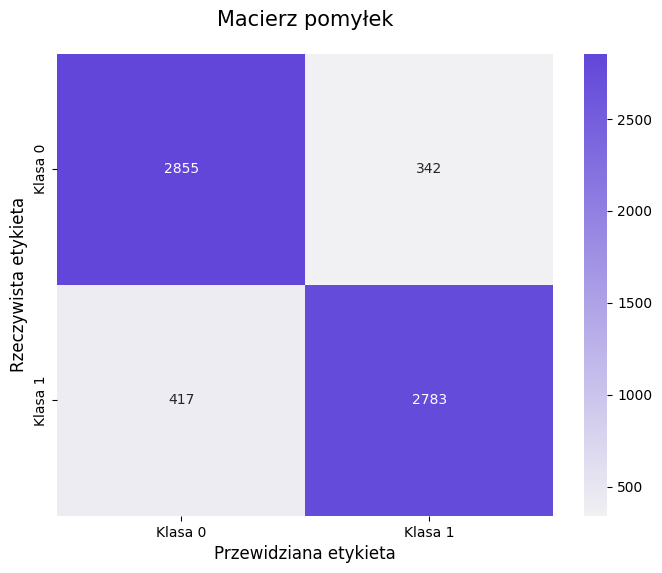

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

my_colors = ["#74d3dc", "#77ade6", "#6146d9", "#3f2da5"]
sns.set_palette(sns.color_palette(my_colors))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(my_colors[2], as_cmap=True), 
            xticklabels=['Klasa 0', 'Klasa 1'], yticklabels=['Klasa 0', 'Klasa 1'])
plt.title('Macierz pomyłek', fontsize=15, pad=20)
plt.xlabel('Przewidziana etykieta', fontsize=12)
plt.ylabel('Rzeczywista etykieta', fontsize=12)
plt.show()


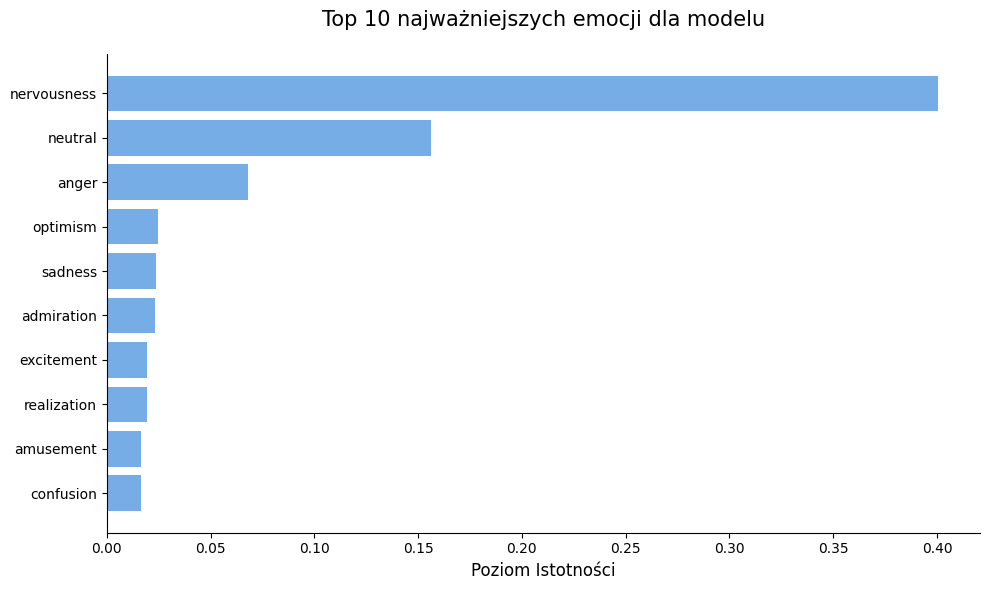

In [60]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color=my_colors[1], align='center')
plt.yticks(range(len(indices)), [emotion_cols[i] for i in indices])
plt.title('Top 10 najważniejszych emocji dla modelu', fontsize=15, pad=20)
plt.xlabel('Poziom Istotności', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

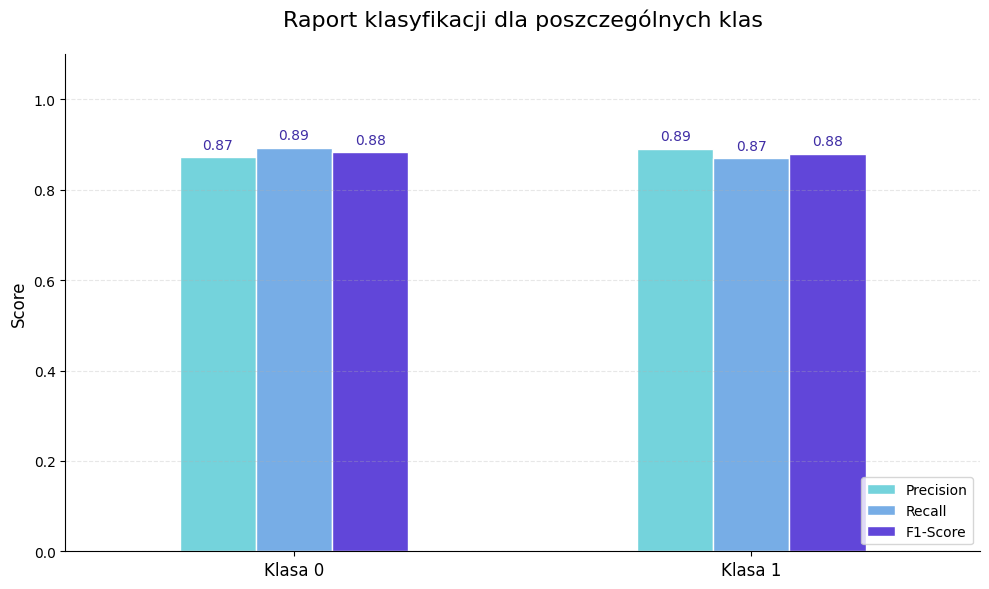

In [62]:

report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

classes_metrics = report_df.iloc[:2, :3] 
global_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg'], :].iloc[:, 0] 

plt.figure(figsize=(10, 6))
ax = classes_metrics.plot(kind='bar', figsize=(10, 6), color=my_colors[:3], edgecolor='white')

plt.title('Raport klasyfikacji dla poszczególnych klas', fontsize=16, pad=20)
plt.xticks(ticks=[0, 1], labels=['Klasa 0', 'Klasa 1'], rotation=0, fontsize=12)
plt.ylim(0, 1.1)
plt.ylabel('Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(['Precision', 'Recall', 'F1-Score'], loc='lower right', frameon=True)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', 
                fontsize=10, color=my_colors[3])

sns.despine()
plt.tight_layout()
plt.show()